# Clase 8 - Aprendizaje Supervisado

## Notebook 3: Regresión Múltiple

Alumno: Sara Valenzuela

Materia: Minería de Datos

Objetivo:

Aplicar un modelo de Regresión Lineal Múltiple para predecir el precio de una vivienda utilizando múltiples variables explicativas y evaluar el desempeño del modelo mediante métricas de regresión.

In [25]:
# Importar librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [26]:
# Crear Datasets

df = pd.DataFrame({
    "Superficie":[50,60,70,80,90,100,110,120,130,140],
    "Habitaciones":[2,2,3,3,3,4,4,4,5,5],
    "Baños":[1,1,2,2,2,2,3,3,3,4],
    "Precio":[100000,120000,150000,170000,190000,220000,250000,280000,310000,350000]
})

df

,Superficie,Habitaciones,Baños,Precio
0,50,2,1,100000
1,60,2,1,120000
2,70,3,2,150000
3,80,3,2,170000
4,90,3,2,190000
5,100,4,2,220000
6,110,4,3,250000
7,120,4,3,280000
8,130,5,3,310000
9,140,5,4,350000


## Exploración inicial de los datos

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Superficie    10 non-null     int64
 1   Habitaciones  10 non-null     int64
 2   Baños         10 non-null     int64
 3   Precio        10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [28]:
df.describe()

,Superficie,Habitaciones,Baños,Precio
count,10.000000,10.000000,10.000000,10.000000
mean,95.000000,3.500000,2.300000,214000.000000
std,30.276504,1.080123,0.948683,82892.165559
min,50.000000,2.000000,1.000000,100000.000000
25%,72.500000,3.000000,2.000000,155000.000000
50%,95.000000,3.500000,2.000000,205000.000000
75%,117.500000,4.000000,3.000000,272500.000000
max,140.000000,5.000000,4.000000,350000.000000


## Matriz de correlación

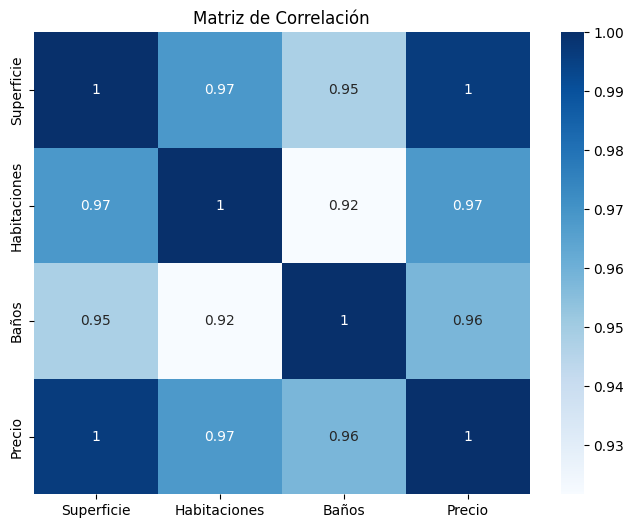

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Matriz de Correlación")

plt.show()

Interpretación:

La matriz de correlación permite identificar la intensidad de la relación entre las variables. Se observa una fuerte correlación positiva entre superficie, cantidad de habitaciones, cantidad de baños y precio de la vivienda. Esto indica que dichas variables son potencialmente útiles para la predicción del precio.

## Definición de variables

In [30]:
X = df[["Superficie","Habitaciones","Baños"]]

y = df["Precio"]

X.head()

,Superficie,Habitaciones,Baños
0,50,2,1
1,60,2,1
2,70,3,2
3,80,3,2
4,90,3,2


## División en entrenamiento y prueba

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Entrenamiento del modelo

In [32]:
modelo = LinearRegression()

modelo.fit(X_train,y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


## Predicciones

In [33]:
y_pred = modelo.predict(X_test)

predicciones = pd.DataFrame({
    "Valor Real":y_test,
    "Valor Predicho":y_pred
})

predicciones

,Valor Real,Valor Predicho
8,310000,303928.571429
1,120000,110714.285714


## Evaluación del modelo

In [34]:
r2 = r2_score(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

mae = mean_absolute_error(y_test,y_pred)

print("R² =", round(r2,4))
print("MSE =", round(mse,2))
print("MAE =", round(mae,2))

R² = 0.9932
MSE = 61543367.35
MAE = 7678.57


##Interpretación:

El valor de R² = 0.9932 indica que el modelo explica aproximadamente el 99.32% de la variabilidad del precio de las viviendas.

El MSE (Error Cuadrático Medio) representa el promedio de los errores al cuadrado entre los valores reales y los predichos.

El MAE (Error Absoluto Medio) representa el error promedio absoluto de las predicciones.

Los resultados obtenidos muestran que el modelo posee una alta capacidad predictiva y un bajo nivel de error para los datos analizados.

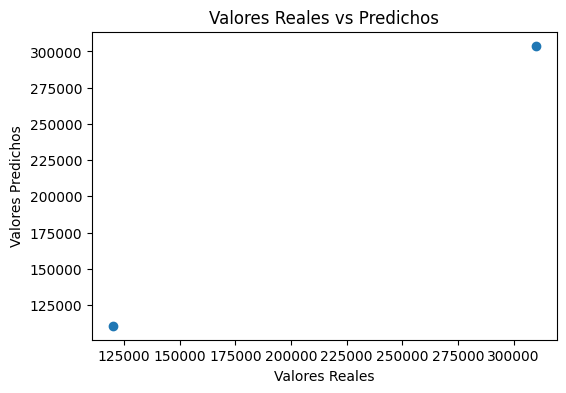

In [35]:
# GRAFICO

plt.figure(figsize=(6,4))

plt.scatter(y_test,y_pred)

plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")

plt.title("Valores Reales vs Predichos")

plt.show()

Interpretación:

Los puntos se ubican próximos a una línea imaginaria de igualdad entre valores reales y predichos. Esto indica que el modelo presenta una buena capacidad para estimar el precio de las viviendas a partir de las variables utilizadas.

In [36]:
coeficientes = pd.DataFrame({
    "Variable":X.columns,
    "Coeficiente":modelo.coef_
})

coeficientes

,Variable,Coeficiente
0,Superficie,2071.428571
1,Habitaciones,4642.857143
2,Baños,17142.857143


Interpretación:

Los coeficientes representan el impacto de cada variable sobre el precio estimado de la vivienda. Un coeficiente positivo indica que, manteniendo constantes las demás variables, un incremento en dicha característica produce un aumento en el precio predicho.

## Comparación entre Regresión Logística y Regresión Múltiple

La Regresión Logística se utiliza para problemas de clasificación, donde la variable objetivo representa categorías.

La Regresión Múltiple se utiliza para problemas de regresión, donde la variable objetivo corresponde a un valor numérico continuo.

En este ejercicio se utilizó Regresión Múltiple porque el objetivo consiste en predecir el precio de una vivienda.

## Conclusión

En este ejercicio se aplicó un modelo de Regresión Lineal Múltiple para estimar el precio de viviendas utilizando superficie, cantidad de habitaciones y cantidad de baños como variables predictoras.

Las métricas R², MSE y MAE permitieron evaluar el desempeño del modelo, mientras que el análisis de correlación y de coeficientes permitió comprender la influencia de cada variable sobre el precio.

Se concluye que la Regresión Múltiple constituye una herramienta adecuada para modelar relaciones entre múltiples variables explicativas y una variable numérica continua.